In [1]:
%load_ext autoreload
%autoreload 2

from os import path
from glob import glob
import itertools

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import mne

from notifmmn import erputils

rawdir = '../data/raw/'
resultdir = '../data/results/'

triggers = dict(
    S14='BN STD',
    S15='SN DEV',
    S24='SN STD',
    S25='BN DEV',
    S34='CN STD',
    S35='BN DEV',
)

%matplotlib widget

In [2]:
participants = pd.read_csv('participant_details.csv', index_col=0)
delays = participants['Tone_delay'].rename('tone delay')
n100_latencies = pd.read_csv(path.join(resultdir, 'n100_latencies.csv'), index_col=[0, 1])

In [3]:
# list all preprocessed files
# preprocessing involves manual curation, band pass filtering,
# down sampling, removal of eye artifacts, and epoching
files = glob(path.join(rawdir, 'preprocessed', '*'))
print(len(files))
sorted(files)

58


['../data/raw/preprocessed/sub-sd011-epo.fif',
 '../data/raw/preprocessed/sub-sd012-epo.fif',
 '../data/raw/preprocessed/sub-sd013-epo.fif',
 '../data/raw/preprocessed/sub-sd015-epo.fif',
 '../data/raw/preprocessed/sub-sd016-epo.fif',
 '../data/raw/preprocessed/sub-sd017-epo.fif',
 '../data/raw/preprocessed/sub-sd018-epo.fif',
 '../data/raw/preprocessed/sub-sd019-epo.fif',
 '../data/raw/preprocessed/sub-sd020-epo.fif',
 '../data/raw/preprocessed/sub-sd021-epo.fif',
 '../data/raw/preprocessed/sub-sd022-epo.fif',
 '../data/raw/preprocessed/sub-sd023-epo.fif',
 '../data/raw/preprocessed/sub-sd024-epo.fif',
 '../data/raw/preprocessed/sub-sd024_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd025-epo.fif',
 '../data/raw/preprocessed/sub-sd025_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd026-epo.fif',
 '../data/raw/preprocessed/sub-sd027-epo.fif',
 '../data/raw/preprocessed/sub-sd028-epo.fif',
 '../data/raw/preprocessed/sub-sd029-epo.fif',
 '../data/raw/preproce

# Bootstrapping to get uncertainty in ERP peaks

## Code development

In [36]:
def compute_single_erp_scores(epochs, window, latency_fractions=[0.25], picks=None, extrema=-1):
    '''
    Returns the following scores for an ERP waveform derived by averaging the epochs
    1. peak amplitude (of the highest peak in the window) [PA]
    2. peak latency (of the highest peak in the window) [PL]
    3. time-window mean amplitude [TWMA]
    4. fractional area latency [FAL]
    '''
    if picks is None:
        picks = epochs[0].columns
    erp = epochs[0][picks].mean(axis=1).groupby('time').mean()
    erp_win = erp.loc[window[0]:window[1]]
    # find the peak of the erp and its amplitude
    t = (extrema*erp_win).idxmax()
    a = erp.loc[t]
    # find the integrated area in the window for the erp
    ia = erp_win.mean()
    # find the latencies for different fractional coverages
    tfs = {}
    # TODO: fractional area latency needs to be fixed!
    for f in latency_fractions:
        tfs[f'FAL_{f}'] = erp_win.index[extrema*erp_win.cumsum()>extrema*erp_win.sum()*f][0]
    return pd.concat([pd.Series(dict(PA=a, PL=t, TWMA=ia)), pd.Series(tfs)], names=['iteration']), [erp]

def compute_dwave_scores(epochs, window, latency_fractions=[0.25], picks=None, extrema=-1):
    '''
    Returns the following scores for an ERP difference wave derived by averaging
    the two groups of epochs and subtracting group 1 from group 0
    1. peak amplitude (of the highest peak in the window) [PA]
    2. peak latency (of the highest peak in the window) [PL]
    3. time-window mean amplitude [TWMA]
    4. fractional area latency [FAL]
    '''
    if picks is None:
        picks = epochs[0].columns
    erp0 = epochs[0][picks].mean(axis=1).groupby('time').mean()
    erp1 = epochs[1][picks].mean(axis=1).groupby('time').mean()
    dwave = erp0 - erp1
    erp_win = dwave.loc[window[0]:window[1]]
    # find the peak of the erp and its amplitude
    t = (extrema*erp_win).idxmax()
    a = dwave.loc[t]
    # find the integrated area in the window for the erp
    ia = erp_win.mean()
    # find the latencies for different fractional coverages
    tfs = {}
    # TODO: fractional area latency needs to be fixed!
    for f in latency_fractions:
        tfs[f'FAL_{f}'] = erp_win.index[extrema*erp_win.cumsum()>extrema*erp_win.sum()*f][0]
    return pd.concat([pd.Series(dict(PA=a, PL=t, TWMA=ia)), pd.Series(tfs)], names=['iteration']), [dwave]

def compute_bootstrapped_scores(epochs, fn, n_iterations, sample_size=None, **kwargs):
    '''
    Compute score(s) with SEM by bootstrapping over epochs
    epochs: an instance of epochs, or list of epoch instances when more than one are required (for example for a difference wave)
    fn: the function to be called to evaluate the parameters for each resampling of epochs
    fn must accept a list of epochs as a pandas dataframe (indexed by epoch and time)
    fn must return a set of scores as a pandas series and the list of generated erps for each input epoch
    n_iterations: number of times resampling should be performed
    sample_size: int or list of ints (number of samples to draw in each iteration). default None will use the same number of samples as original epochs instance
    kwargs: arguments to be passed to the function fn
    '''
    if not isinstance(epochs, list):
        epochs = [epochs]
    if sample_size is None:
        sample_size = [len(x) for x in epochs]
    # convert epochs to dataframes for faster computation inside the loop
    epochs = [
        e.to_data_frame().drop('condition', axis=1).set_index(['time', 'epoch']).unstack('time') for e in epochs
    ]
    scores, erps = {}, {}
    itr, errs = 0, []
    with tqdm(total=n_iterations, desc='iter') as pbar:
        while itr < n_iterations:
            try:
                _epochs = []
                # generate bootstrapped epochs
                for epoch, ss in zip(epochs, sample_size):
                    _epochs.append(
                        epoch.sample(ss, replace=True).stack('time', future_stack=True)
                    )
                # generate corresponding scores
                scores[itr], erps[itr] = fn(_epochs, **kwargs)
                itr += 1
                pbar.update(1)
            except Exception as e:
                errs.append(e)
                # print(e)
                # if too many iterations are failing, break to get out of the loop
                if len(errs)>=100:
                    break
    return pd.concat(scores, names=['iteration', 'score']).unstack('score'), erps, errs

def get_erp_sem(epochs, n_iterations, sample_size=None, verifiplot=True, **kwargs):
    '''
    Returns the scores, erps, errors (encountered in each bootstrapped iteration) and figure object (if verifiplot)
    epochs: if single epochs instance, computes single erp scores
            if list of two epochs, computes the scores for the difference wave
    n_iterations: number of bootstrap iterations to run
    sample_size: number of epochs in each bootstrap iteration (defaults to the number of epochs in original epochs)
    verifiplot: setting True (default) will plot the ERPs (or difference waves) across bootstrapped iterations
    kwargs: arguments required for single wave or difference wave score computation
    kwargs include window (tuple), latency_fractions (list, for computing fractional area latencies), picks (to average over), extrema (whether to find minima or maxima)
    '''
    if not isinstance(epochs, list):
        epochs = [epochs]
    if len(epochs)==1:
        scores, erps, errs = compute_bootstrapped_scores(
            epochs, compute_single_erp_scores, n_iterations=n_iterations, sample_size=sample_size, **kwargs
        )
    elif len(epochs)==2:
        scores, erps, errs = compute_bootstrapped_scores(
            epochs, compute_dwave_scores, n_iterations=n_iterations, sample_size=sample_size, **kwargs
        )
    else:
        raise ValueError('exactly one or two sets of epochs must be given.')
    erps = pd.concat({k:v[0] for k, v in erps.items()}, axis=1)

    f = None
    if verifiplot:
        window = kwargs.pop('window')
        f, ax = plt.subplots(figsize=(8, 3), tight_layout=True)
        erps.plot(ax=ax, c='C0', alpha=0.01, legend=False)
        ax.scatter(scores.PL, scores.PA, s=1, c='k')
        ax.set_xlabel('time (s)')
        ax.set_ylabel('voltage ($\mu V$)')
        ax.axvspan(*window, color='gray', alpha=0.1)
        ax.annotate(
            scores.aggregate(['mean', 'std']).to_string(float_format='{:.3f}'.format, col_space=8, justify='right'),
            (10, 10), xycoords='axes pixels', family='monospace'
        )
    return scores, erps, errs, f

In [5]:
fname = '../data/raw/preprocessed/sub-sd025-epo.fif'
sub = path.basename(fname).split('-')[1]
_epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')
epochs = _epochs.to_data_frame()
epochs[['stim', 'kind']] = epochs.condition.map(triggers).str.split(' ', expand=True)
epochs = epochs.drop('condition', axis=1).set_index(['stim', 'kind', 'epoch', 'time']).sort_index()
epochs

Fp1        Fz        F3         F7  \
stim kind epoch time                                                  
BN   DEV  858   -0.300781   4.564826  1.776591  1.174929   4.686250   
                -0.298828   5.543532  3.650788  2.733936   5.597657   
                -0.296875   6.347458  5.518270  4.109418   6.374919   
                -0.294922   6.916531  7.279775  5.257930   6.988595   
                -0.292969   7.213236  8.846846  6.134596   7.415818   
...                              ...       ...       ...        ...   
SN   STD  1693   0.892578  20.689120  1.857935  6.434315  10.761470   
                 0.894531  21.589099  2.421585  7.022500  11.418317   
                 0.896484  22.095740  2.637767  7.244707  11.783718   
                 0.898438  22.173931  2.475618  7.078362  11.846821   
                 0.900391  21.823868  1.939190  6.537846  11.623971   

                                 FT9        FC5       FC1         C3  \
stim kind epoch time                                                   
BN   DEV  858   -0.300781  -0.549503   4.935875  1.062601   6.348017   
                -0.298828  -0.191843   5.491024  2.450836   7.956669   
                -0.296875   0.382067   5.760312  3.784581   9.405551   
                -0.294922   1.131142   5.788387  5.000832  10.658116   
                -0.292969   1.979171   5.635867  6.050790  11.685140   
...                              ...        ...       ...        ...   
SN   STD  1693   0.892578  14.976724 -21.450666 -0.897633   4.026464   
                 0.894531  15.832848 -20.664513  0.077575   5.903242   
                 0.896484  16.338982 -20.054101  0.794671   7.550062   
                 0.898438  16.447375 -19.651918  1.238337   8.923232   
                 0.900391  16.158822 -19.481767  1.413054   9.994361   

                                  T7       TP9  ...         C6         C2  \
stim kind epoch time                            ...                         
BN   DEV  858   -0.300781   1.040457 -3.987702  ...   2.676706  10.610050   
                -0.298828   1.615210 -4.461302  ...   2.303319   9.106677   
                -0.296875   2.110433 -4.830866  ...   2.097951   7.625482   
                -0.294922   2.491943 -5.014963  ...   2.007314   6.294122   
                -0.292969   2.729518 -4.965729  ...   1.975240   5.205516   
...                              ...       ...  ...        ...        ...   
SN   STD  1693   0.892578  18.327871  2.526359  ...  12.084774  10.818876   
                 0.894531  19.129381  2.431822  ...  12.307575  10.034906   
                 0.896484  19.290684  2.246492  ...  12.009231   9.262910   
                 0.898438  18.750373  1.960597  ...  11.206119   8.582025   
                 0.900391  17.508598  1.576303  ...   9.987844   8.048590   

                                 FC4        FT8         F6        AF8  \
stim kind epoch time                                                    
BN   DEV  858   -0.300781  10.580730   7.803944  -2.933964   8.256402   
                -0.298828  11.720212   9.354172  -2.042894   9.180654   
                -0.296875  12.755222  10.657086  -1.197844   9.793392   
                -0.294922  13.612278  11.607783  -0.575178  10.021166   
                -0.292969  14.229665  12.129825  -0.302668   9.839225   
...                              ...        ...        ...        ...   
SN   STD  1693   0.892578   3.983378   9.467377  21.546908   4.112322   
                 0.894531   4.511207   9.524519  21.791022   4.253451   
                 0.896484   4.820441   9.314076  22.120180   4.273880   
                 0.898438   4.941672   8.870407  22.547676   4.160348   
                 0.900391   4.922615   8.236843  23.090553   3.901514   

                                 AF4        F2        FCz         Cz  
stim kind epoch time                                                  
BN   DEV  858   -0.300781   1.721527  6.336573  -0.163598   9.325209  
       

PA         -4.235166
PL          0.220703
TWMA       -2.487144
FAL_0.01    0.185547
FAL_0.25    0.208984
FAL_0.5     0.220703
FAL_0.99    0.250000
dtype: float64

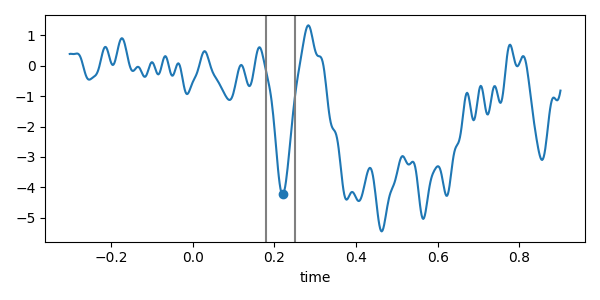

In [15]:
# test the erp_scores function
__epochs = _epochs.to_data_frame().drop('condition', axis=1).set_index(['time', 'epoch']).unstack('time').sample(100, replace=True).stack('time', future_stack=True)
window = (0.18, 0.25)

scores, erp = compute_single_erp_scores([__epochs], window=window, latency_fractions=[0.01, 0.25, 0.5, 0.99])
erp = erp[0]

f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
erp.plot(ax=ax)
ax.axvline(window[0], c='gray')
ax.axvline(window[1], c='gray')
ax.scatter([scores['PL']], [scores['PA']])
# ax.axvspan(scores['FAL_0.01'], scores['FAL_0.25'], color='r')
# ax.axvspan(scores['FAL_0.25'], scores['FAL_0.5'], color='g')
# ax.axvspan(scores['FAL_0.5'], scores['FAL_0.99'], color='gray')

scores

iter:   0%|          | 0/50 [00:00<?, ?it/s]

iter:   0%|          | 0/50 [00:00<?, ?it/s]

Text(1.0, 0.9, 'SN')

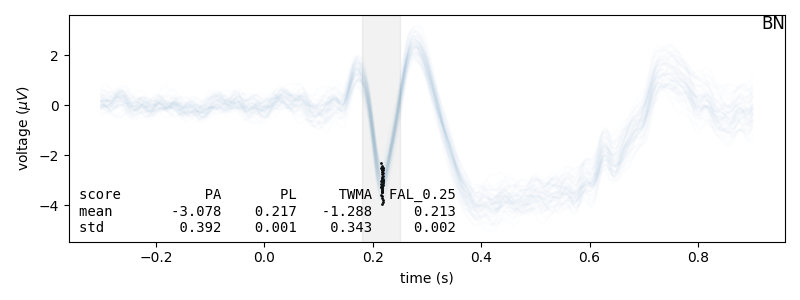

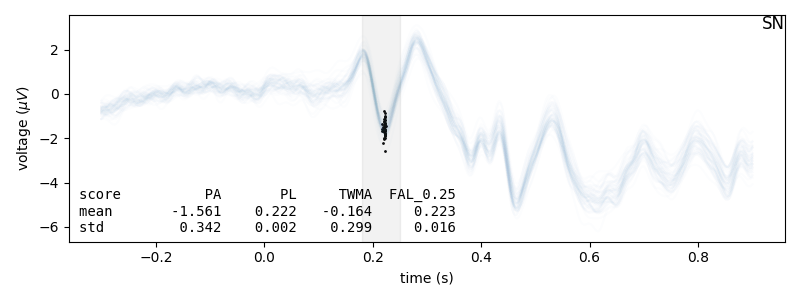

In [46]:
# test bootstrapping function for single ERPs
n1_win = (0.18, 0.25)
scores_bn, _, errs, f_bn = get_erp_sem(_epochs['S14'], n_iterations=50, window=window, picks=['Fz', 'FCz', 'Cz'])
scores_sn, _, errs, f_sn = get_erp_sem(_epochs['S24'], n_iterations=50, window=window, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right');

iter:   0%|          | 0/500 [00:00<?, ?it/s]

iter:   0%|          | 0/500 [00:00<?, ?it/s]

Text(1.0, 0.9, 'SN')

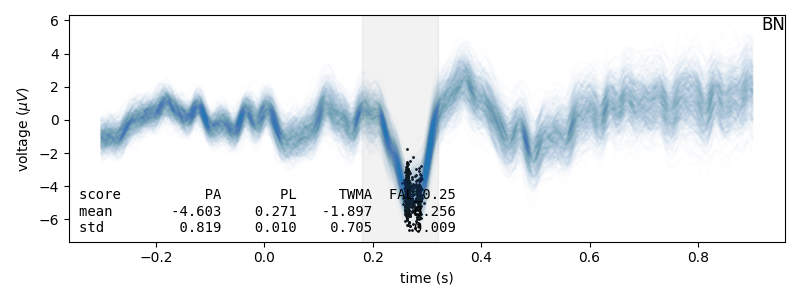

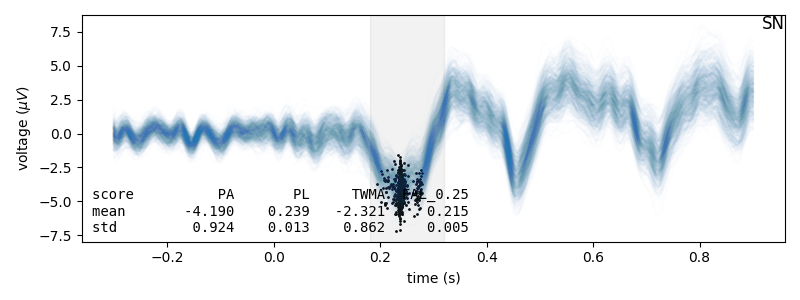

In [47]:
# test bootstrapping function for difference wave (MMN) ERPs
mmn_win = (0.18, 0.32)
scores_bn, _, errs, f_bn = get_erp_sem([_epochs['S25'], _epochs['S14']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, _, errs, f_sn = get_erp_sem([_epochs['S15'], _epochs['S24']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right');

## Usage example with library
In the example, only 50 iterations are used to run it faster. However at least 1000 iterations should be used for final analysis.

In [52]:
# load the data
fname = '../data/raw/preprocessed/sub-sd025-epo.fif'
sub = path.basename(fname).split('-')[1]
_epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')

iter:   0%|          | 0/50 [00:00<?, ?it/s]

iter:   0%|          | 0/50 [00:00<?, ?it/s]

BN scores:


score,PA,PL,TWMA,FAL_0.25
mean,-2.971622,0.217070,-1.192002,0.213203
std,0.283204,0.001045,0.274600,0.001987


SN scores:


score,PA,PL,TWMA,FAL_0.25
mean,-1.486368,0.221992,-0.106527,0.222969
std,0.272418,0.001747,0.250296,0.017489


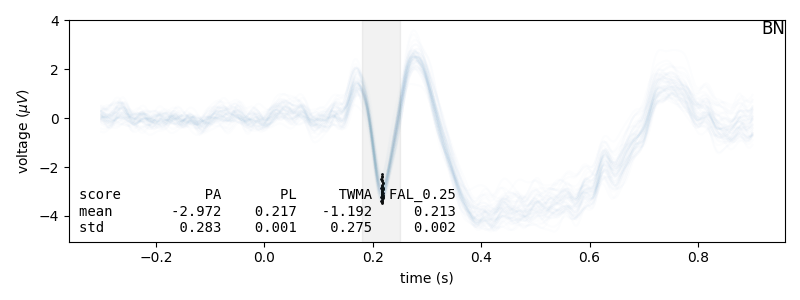

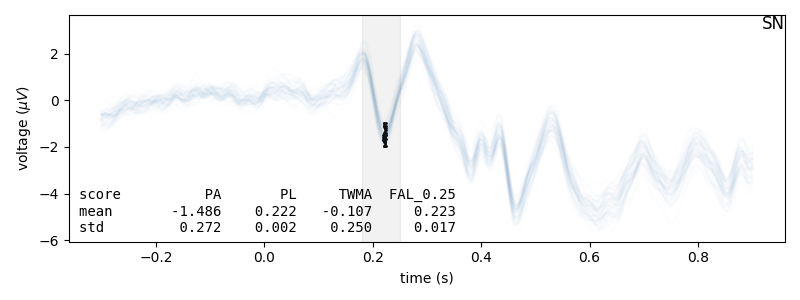

In [51]:
# get N1 scores
# in general N1 windows can be defined between tone_delay + 0.18 to tone_delay+0.24 (seconds)
# tone delays can be read from `participant_details.csv`
n1_win = (0.18, 0.25)
scores_bn, _, errs, f_bn = erputils.get_erp_sem(_epochs['S14'], n_iterations=50, window=n1_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, _, errs, f_sn = erputils.get_erp_sem(_epochs['S24'], n_iterations=50, window=n1_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right')
print('BN scores:')
display(scores_bn.aggregate(['mean', 'std']))
print('SN scores:')
display(scores_sn.aggregate(['mean', 'std']))

iter:   0%|          | 0/50 [00:00<?, ?it/s]

iter:   0%|          | 0/50 [00:00<?, ?it/s]

BN scores:


score,PA,PL,TWMA,FAL_0.25
mean,-4.634882,0.269883,-1.973532,0.255195
std,0.904365,0.009226,0.775022,0.008642


SN scores:


score,PA,PL,TWMA,FAL_0.25
mean,-4.276512,0.241992,-2.458929,0.214844
std,0.838497,0.014002,0.689317,0.004464


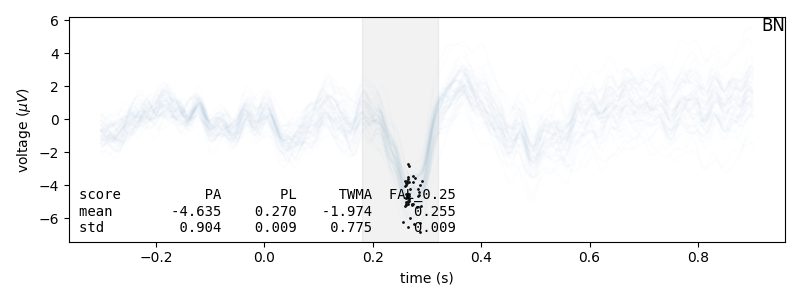

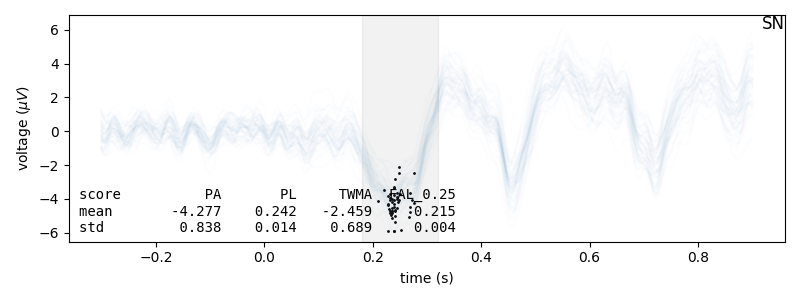

In [53]:
# get MMN scores
# note that latencies have to be adjusted to account for N1 latencies
# the function returns latencies wrt epoch (ie stimulus onset)
mmn_win = (0.18, 0.32)
scores_bn, _, errs, f_bn = get_erp_sem([_epochs['S25'], _epochs['S14']], n_iterations=50, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, _, errs, f_sn = get_erp_sem([_epochs['S15'], _epochs['S24']], n_iterations=50, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right')
print('BN scores:')
display(scores_bn.aggregate(['mean', 'std']))
print('SN scores:')
display(scores_sn.aggregate(['mean', 'std']))

# Other things

In [23]:
# dependence on sample size
params = {}
for s in tqdm(np.linspace(1, 40, 40)*50):
    params[s], erps, n_failed, f = erputils.get_bootstrapped_latency_amplitude(
        epochs.loc[('SN', 'STD')][['FCz', 'Fz', 'Cz']].mean(axis=1).unstack('time'),
        sample_size=int(s), n_iterations=1000, approx_latency=0.22, verify_plot=False
    )

  0%|          | 0/40 [00:00<?, ?it/s]

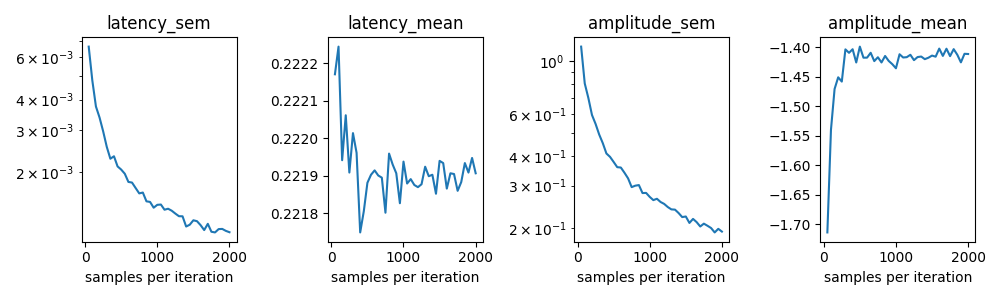

In [24]:
f, axes = plt.subplots(1, 4, figsize=(10, 3), tight_layout=True)
for ax, key in zip(axes, ['latency_sem', 'latency_mean', 'amplitude_sem', 'amplitude_mean']):
    ax.plot(*np.array([(k, params[k][key]) for k in params.keys()]).T)
    ax.set_title(key)
    ax.set_xlabel('samples per iteration')
axes[0].set_yscale('log')
axes[2].set_yscale('log')

Next steps:
- [ ] For each subject with good N1, get mean and SEM of SN and BN N1 latency and amplitude; save it in a csv dataframe.
- [ ] In the scatter plot of tone delay vs N1 latency, include errorbars based on latency MMN (and color the points by tone)
- [ ] For each subject with good N1, get mean and SEM of SN and BN MMN latency and amplitude. Save it in a csv dataframe.
- [ ] Make a scatter plot of BN MMN latency vs SN MMN latency including both x and y errorbars; include a x=y line for reference
- [ ] Make a scatter plot of BN MMN amplitude vs SN MMN amplitude including both x and y errorbars; include a x=y line for reference
- [ ] Other things that make sense to you; I will share more tomorrow